#Titanic Dataset - Exploratory Data Analysis (EDA)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# ----------------------------------------------------------------
# 0. SETUP
# ----------------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "Titanic-Dataset.csv"     # change path if needed

df = pd.read_csv(DATA_PATH)

# Quick look
print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nColumn dtypes:\n", df.dtypes)

Shape: (891, 12)

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37

In [3]:
# 1. SUMMARY STATISTICS
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("1. SUMMARY STATISTICS")
print("=" * 60)

# Numeric summary: mean, median, std, min, max, quartiles
numeric_cols = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
summary = df[numeric_cols].describe().T
summary["median"] = df[numeric_cols].median()
summary["skew"] = df[numeric_cols].skew()
print(summary)

# Missing values
print("\nMissing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Categorical distribution
print("\nSurvived counts:\n", df["Survived"].value_counts(normalize=True))
print("\nSex counts:\n", df["Sex"].value_counts())
print("\nPclass counts:\n", df["Pclass"].value_counts())
print("\nEmbarked counts:\n", df["Embarked"].value_counts())


1. SUMMARY STATISTICS
        count       mean        std   min      25%      50%   75%       max  \
Age     714.0  29.699118  14.526497  0.42  20.1250  28.0000  38.0   80.0000   
Fare    891.0  32.204208  49.693429  0.00   7.9104  14.4542  31.0  512.3292   
SibSp   891.0   0.523008   1.102743  0.00   0.0000   0.0000   1.0    8.0000   
Parch   891.0   0.381594   0.806057  0.00   0.0000   0.0000   0.0    6.0000   
Pclass  891.0   2.308642   0.836071  1.00   2.0000   3.0000   3.0    3.0000   

         median      skew  
Age     28.0000  0.389108  
Fare    14.4542  4.787317  
SibSp    0.0000  3.695352  
Parch    0.0000  2.749117  
Pclass   3.0000 -0.630548  

Missing values per column:
 Age         177
Cabin       687
Embarked      2
dtype: int64

Survived counts:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Sex counts:
 Sex
male      577
female    314
Name: count, dtype: int64

Pclass counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embar


2. HISTOGRAMS & BOXPLOTS


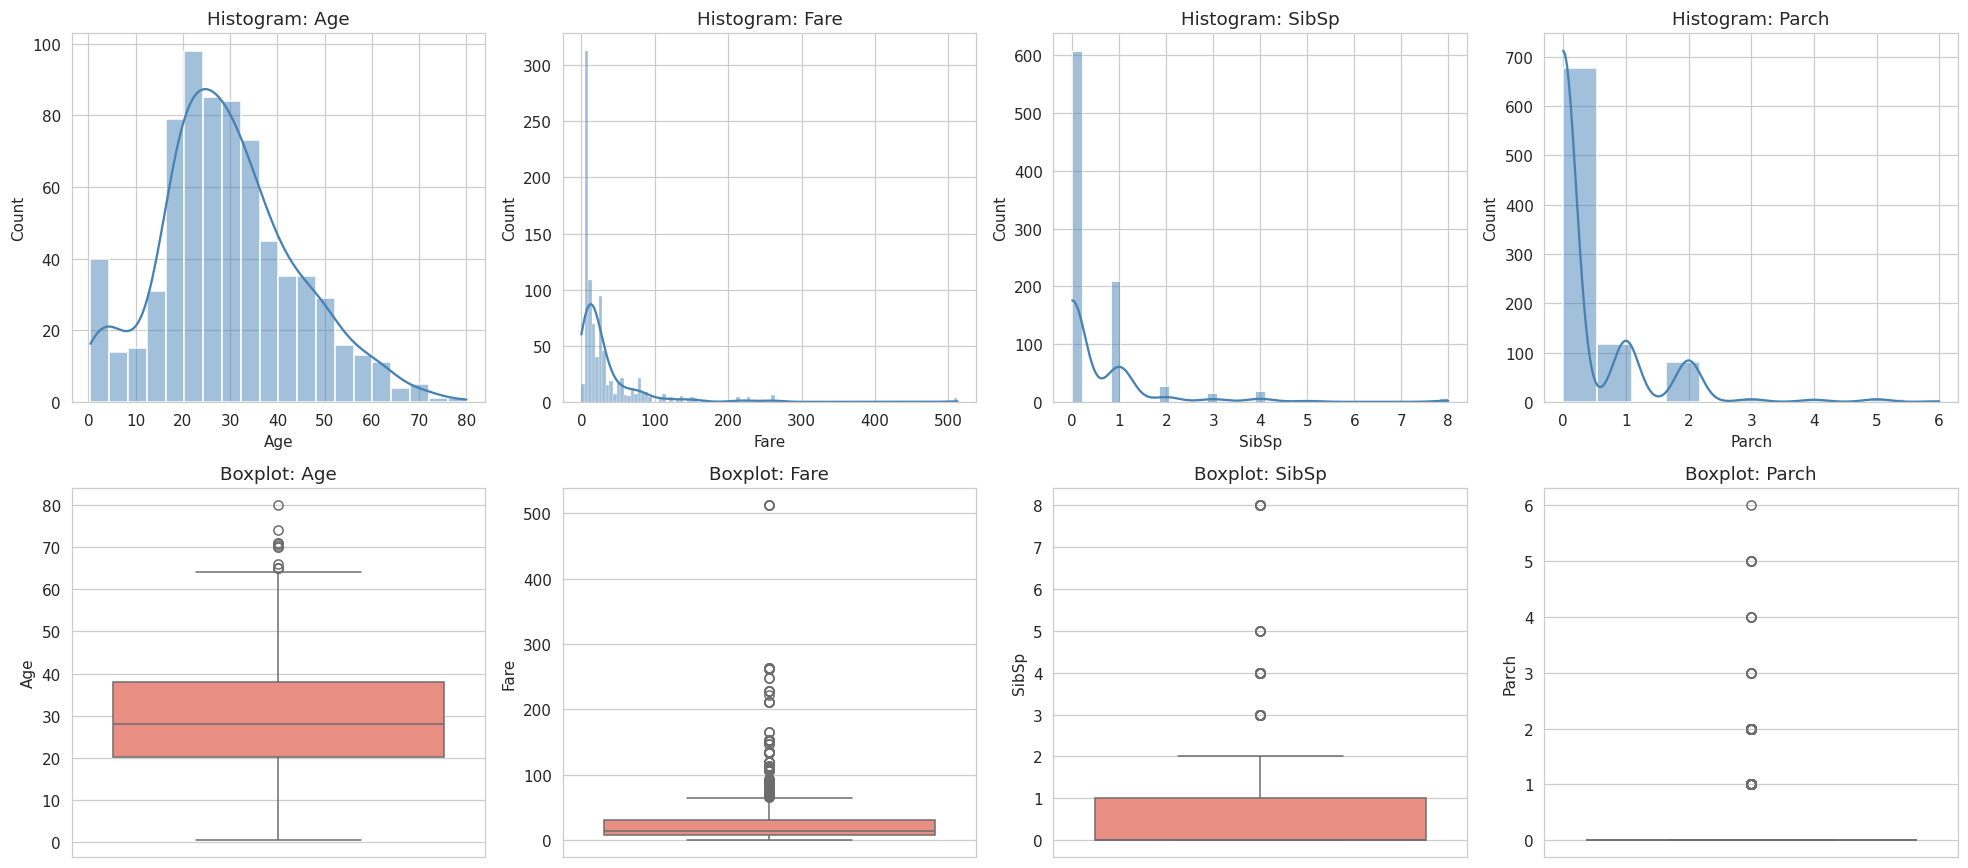

/tmp/ipykernel_2046/1567052907.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Survived", ax=axes[0], palette="Set2")
/tmp/ipykernel_2046/1567052907.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], palette="Set2", errorbar=None)
/tmp/ipykernel_2046/1567052907.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Sex", y="Survived", ax=axes[2], palette="Set2", errorbar=None)


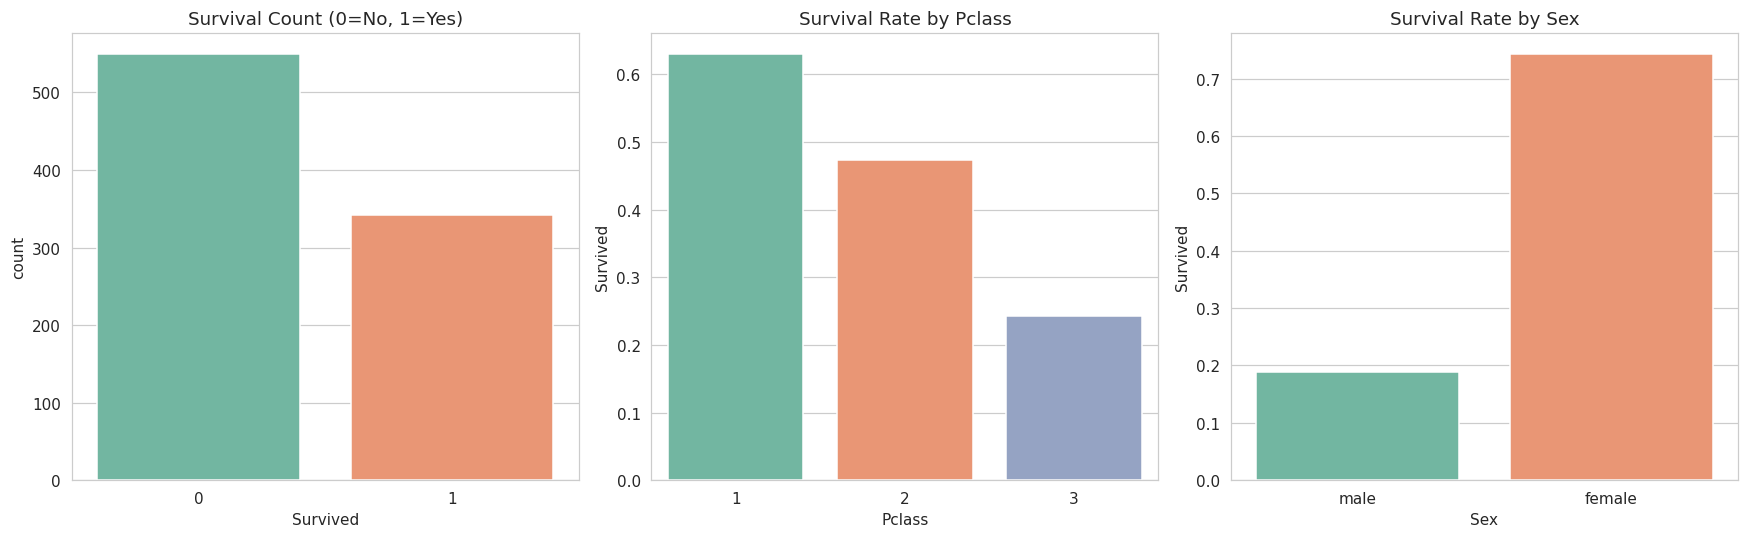

In [4]:
# ----------------------------------------------------------------
# 2. HISTOGRAMS & BOXPLOTS FOR NUMERIC FEATURES
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("2. HISTOGRAMS & BOXPLOTS")
print("=" * 60)

num_features = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, len(num_features), figsize=(18, 8))
for i, col in enumerate(num_features):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Histogram: {col}")

    sns.boxplot(y=df[col], ax=axes[1, i], color="salmon")
    axes[1, i].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

# Survival count & rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.countplot(data=df, x="Survived", ax=axes[0], palette="Set2")
axes[0].set_title("Survival Count (0=No, 1=Yes)")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], palette="Set2", errorbar=None)
axes[1].set_title("Survival Rate by Pclass")

sns.barplot(data=df, x="Sex", y="Survived", ax=axes[2], palette="Set2", errorbar=None)
axes[2].set_title("Survival Rate by Sex")

plt.tight_layout()
plt.show()


3. CORRELATION MATRIX / PAIRPLOT
          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307
Pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500
Age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
SibSp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651
Parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225
Fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000


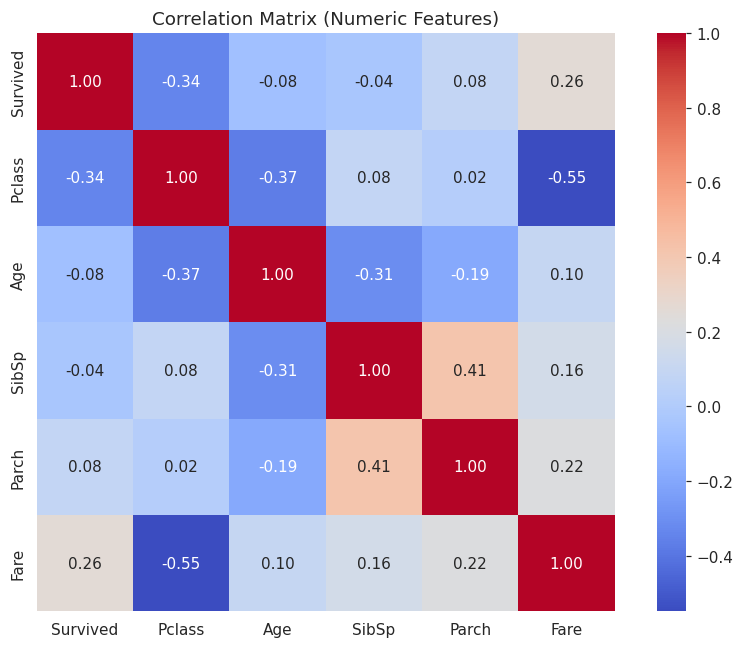

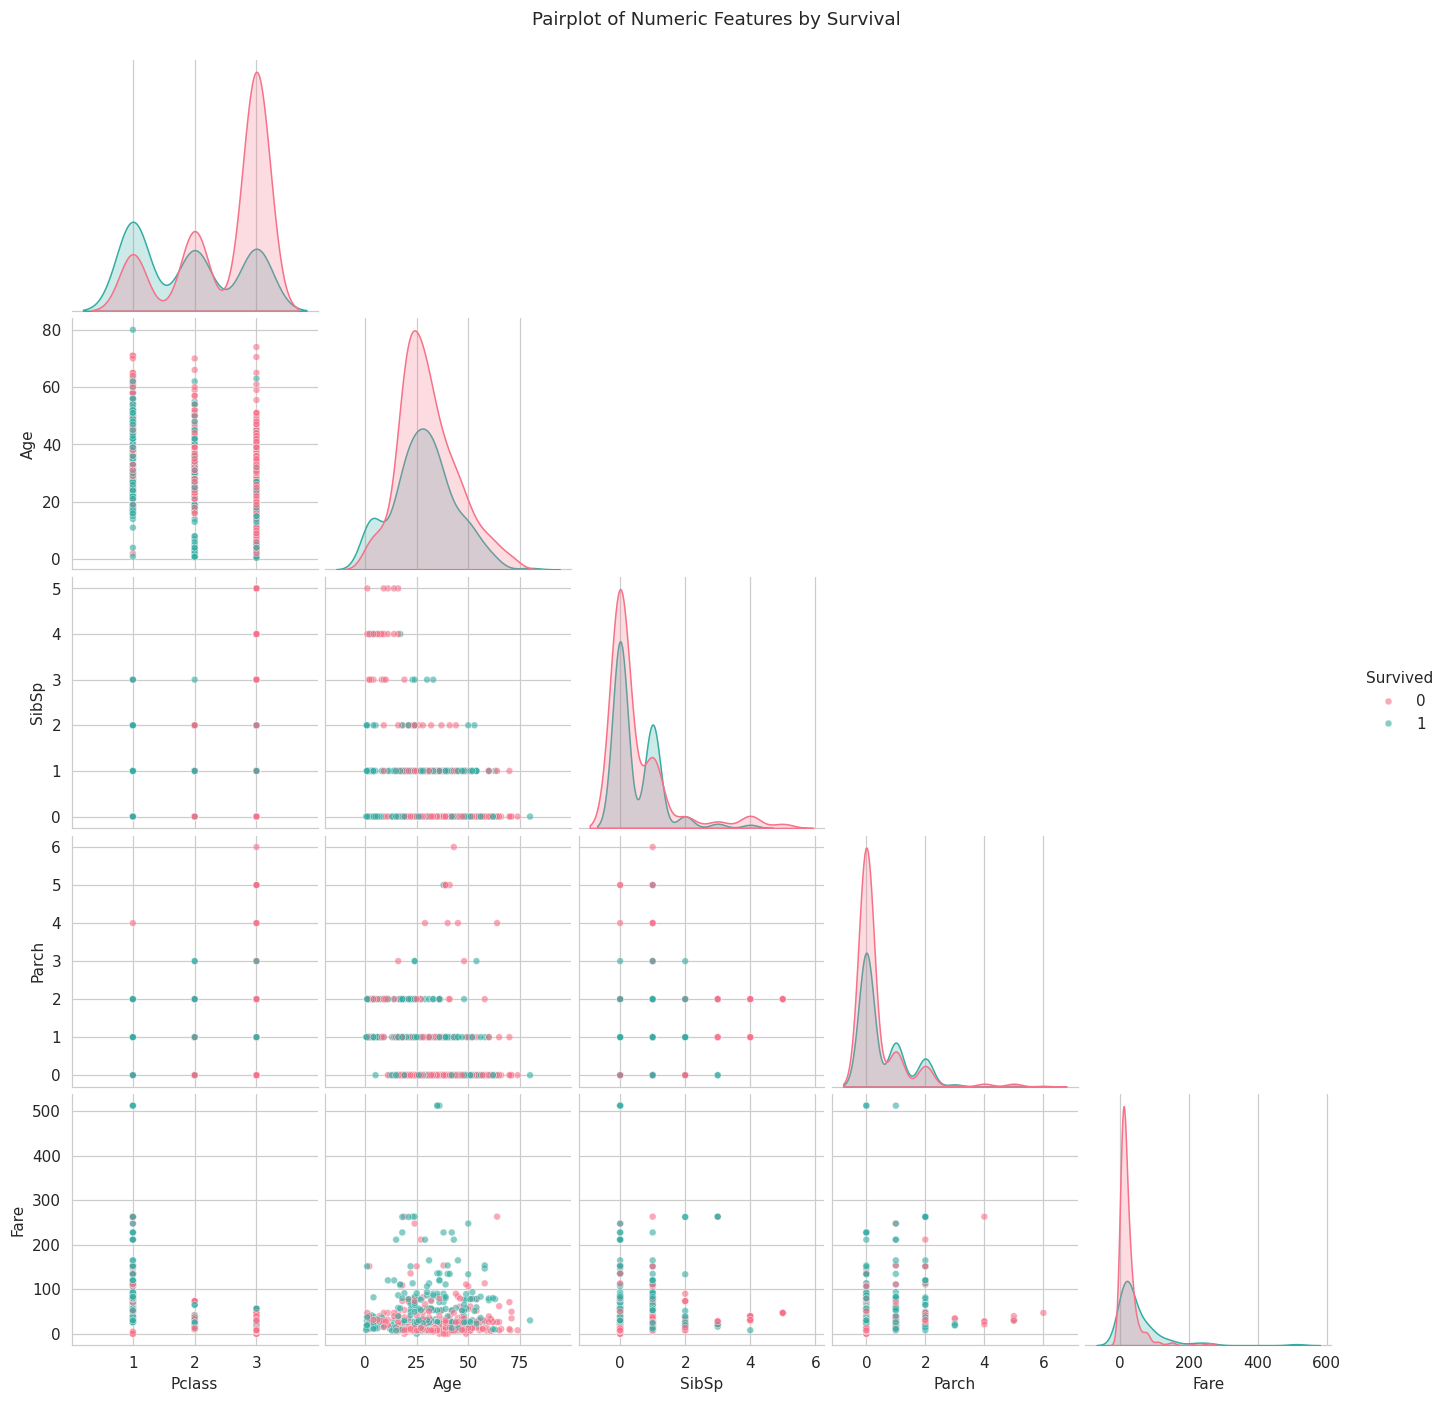

In [5]:
# ----------------------------------------------------------------
# 3. CORRELATION MATRIX & PAIRPLOT
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("3. CORRELATION MATRIX / PAIRPLOT")
print("=" * 60)

corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df[corr_cols].corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

# Pairplot (subset for readability), colored by Survived
pair_df = df[corr_cols].dropna()
pairgrid = sns.pairplot(pair_df, hue="Survived", palette="husl",
                         diag_kind="kde", corner=True, plot_kws={"alpha": 0.6, "s": 20})
pairgrid.fig.suptitle("Pairplot of Numeric Features by Survival", y=1.02)
plt.show()


4. PATTERN & ANOMALY DETECTION
Age: 11 outliers detected (range: 65.00 to 80.00)
Fare: 116 outliers detected (range: 66.60 to 512.33)


/tmp/ipykernel_2046/2169606034.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




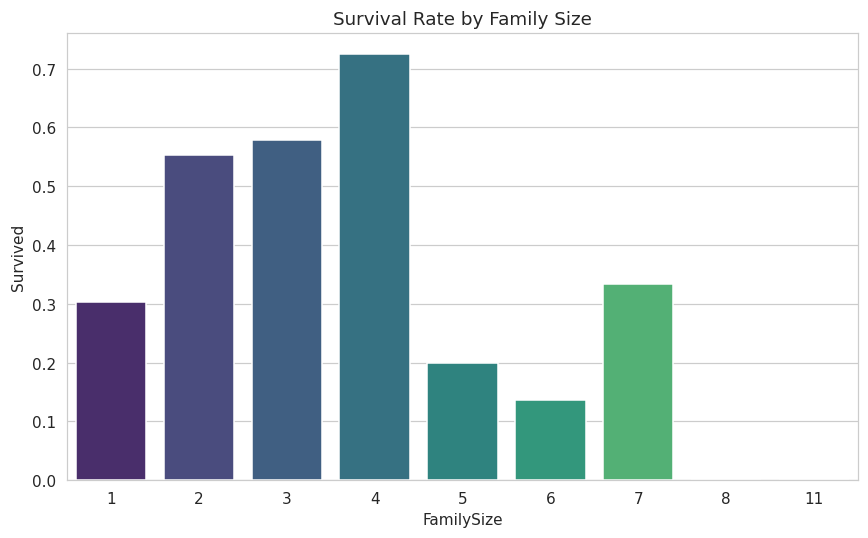

In [6]:
# 4. PATTERNS / TRENDS / ANOMALIES
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("4. PATTERN & ANOMALY DETECTION")
print("=" * 60)

# Outlier detection using IQR method
def detect_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

for col in ["Age", "Fare"]:
    outliers = detect_outliers_iqr(df[col].dropna())
    print(f"{col}: {len(outliers)} outliers detected "
          f"(range: {outliers.min():.2f} to {outliers.max():.2f})" if len(outliers) else f"{col}: no outliers")

# Age distribution by survival (interactive Plotly)
fig_plotly = px.histogram(df, x="Age", color="Survived", barmode="overlay",
                           nbins=30, title="Age Distribution by Survival Status",
                           color_discrete_map={0: "indianred", 1: "seagreen"})
fig_plotly.show()

# Family size feature engineering + pattern check
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="FamilySize", y="Survived", errorbar=None, palette="viridis")
plt.title("Survival Rate by Family Size")
plt.tight_layout()
plt.show()

In [7]:
# ----------------------------------------------------------------
# 5. FEATURE-LEVEL INFERENCES (printed as text)
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("5. KEY INFERENCES")
print("=" * 60)

inferences = []

surv_rate_by_sex = df.groupby("Sex")["Survived"].mean()
inferences.append(
    f"- Females had a much higher survival rate ({surv_rate_by_sex['female']:.2%}) "
    f"than males ({surv_rate_by_sex['male']:.2%}) -> 'women first' evacuation pattern."
)

surv_rate_by_class = df.groupby("Pclass")["Survived"].mean()
inferences.append(
    f"- 1st class passengers survived at {surv_rate_by_class[1]:.2%} vs "
    f"{surv_rate_by_class[3]:.2%} for 3rd class -> socio-economic status impacted survival."
)

inferences.append(
    f"- Fare is right-skewed (skew={df['Fare'].skew():.2f}) with extreme high-fare outliers "
    f"(max={df['Fare'].max():.2f}), likely luxury cabins."
)

inferences.append(
    f"- Age has {df['Age'].isnull().sum()} missing values ({df['Age'].isnull().mean():.1%}) "
    f"-> needs imputation before modeling."
)

inferences.append(
    "- Cabin has >75% missing values -> consider dropping or engineering a 'HasCabin' binary feature."
)

inferences.append(
    f"- Correlation shows Fare (+{corr_matrix.loc['Survived','Fare']:.2f}) positively linked to survival, "
    f"while Pclass ({corr_matrix.loc['Survived','Pclass']:.2f}) is negatively linked "
    "(higher class number = lower class = lower survival)."
)

inferences.append(
    "- Passengers with moderate family size (2-4) survived more than solo travelers or very large families "
    "-> possible 'helped each other but overwhelmed in big groups' effect."
)

for i in inferences:
    print(i)

print("\nEDA complete.")



5. KEY INFERENCES
- Females had a much higher survival rate (74.20%) than males (18.89%) -> 'women first' evacuation pattern.
- 1st class passengers survived at 62.96% vs 24.24% for 3rd class -> socio-economic status impacted survival.
- Fare is right-skewed (skew=4.79) with extreme high-fare outliers (max=512.33), likely luxury cabins.
- Age has 177 missing values (19.9%) -> needs imputation before modeling.
- Cabin has >75% missing values -> consider dropping or engineering a 'HasCabin' binary feature.
- Correlation shows Fare (+0.26) positively linked to survival, while Pclass (-0.34) is negatively linked (higher class number = lower class = lower survival).
- Passengers with moderate family size (2-4) survived more than solo travelers or very large families -> possible 'helped each other but overwhelmed in big groups' effect.

EDA complete.
